# Sparsification Experiments — SRUNetHeavy

Анализ результатов четырёх методов ускорения модели:
1. **Magnitude Pruning** — обнуление наименьших весов (без реального speedup)
2. **Group Convolution** — замена обычных свёрток на grouped
3. **Structural Pruning** — физическое удаление каналов (реальный speedup)
4. **2:4 Semi-Structured Sparsity** — аппаратное ускорение через cuSPARSELt

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

In [20]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

RESULTS = Path('../results/andrey-results')

def load(name):
    return json.loads((RESULTS / name).read_text())

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 14,
    'font.weight': 'bold',
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 14,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'lines.linewidth': 2.5,
    'lines.markersize': 8,
})

---
## 1. Magnitude Pruning (глобальный, неструктурный)

**Идея:** берём все веса модели, сортируем по абсолютному значению, обнуляем N% наименьших.

**Почему нет ускорения?**  
Тензоры остаются того же размера — просто часть элементов равна нулю. GPU не умеет автоматически пропускать нулевые умножения в обычных `Conv2d`/`Linear`. Speedup ≈ 1.0 на всех уровнях спарсности.  
Для реального ускорения нужна либо структурная*спарсность (убираем целые каналы), либо аппаратная поддержка (2:4 на Ampere).

Однако анализы на A100 (ampere поколение GPU) показали, что даже там не наблюдается ускорение при замене Conv2d на Linear

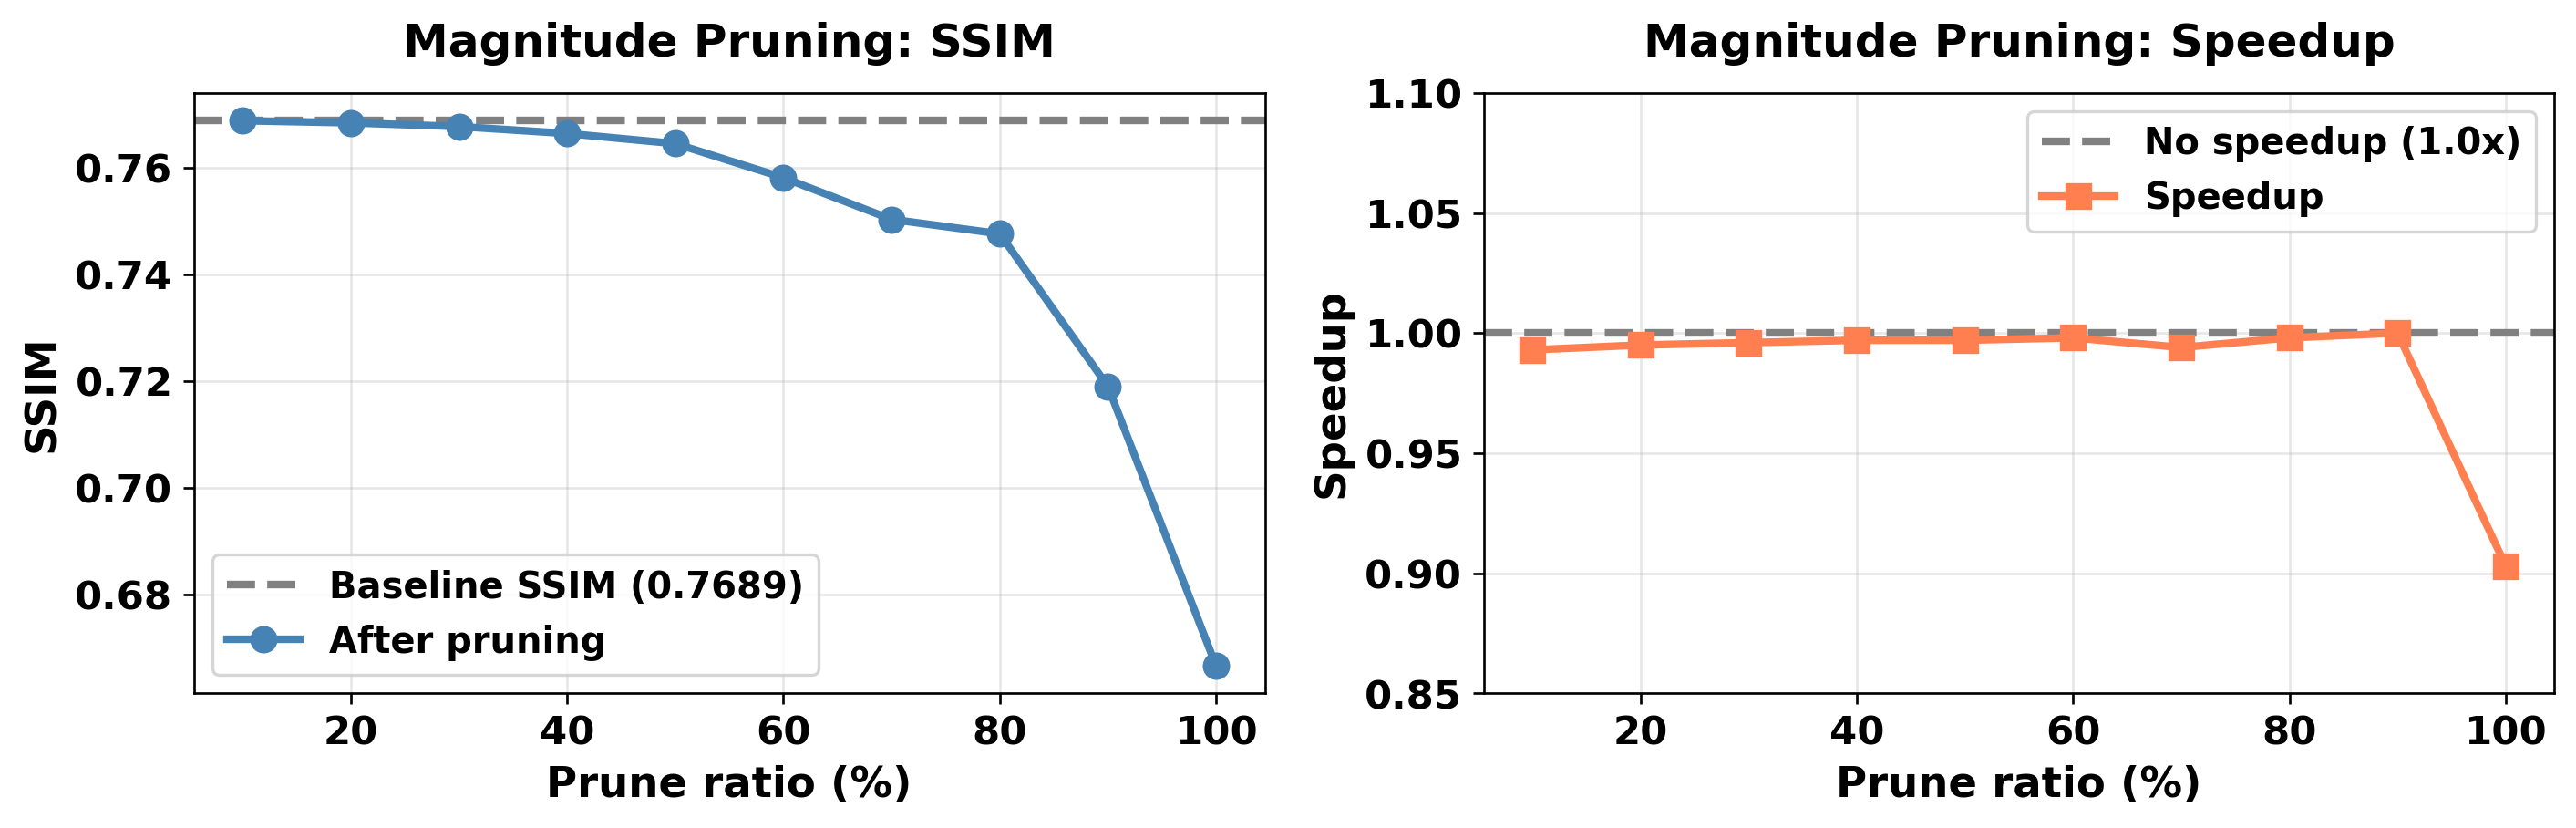

Вывод: speedup примерно 1.0 на всех уровнях — тензоры плотные, ускорения нет.


In [24]:
prune_files = sorted(RESULTS.glob('prune_*.json'), key=lambda p: p.stem)
prune_data = [json.loads(p.read_text()) for p in prune_files]

ratios   = [d['prune_ratio'] for d in prune_data]
ssim_b   = [d['baseline']['ssim'] for d in prune_data]
ssim_r   = [d['result']['ssim'] for d in prune_data]
speedups = [d['speedup'] for d in prune_data]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.axhline(ssim_b[0], color='gray', linestyle='--', lw=2.5, label=f'Baseline SSIM ({ssim_b[0]:.4f})')
ax.plot([r*100 for r in ratios], ssim_r, 'o-', color='steelblue', label='After pruning')
ax.set_xlabel('Prune ratio (%)')
ax.set_ylabel('SSIM')
ax.set_title('Magnitude Pruning: SSIM', pad=12)
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.axhline(1.0, color='gray', linestyle='--', lw=2.5, label='No speedup (1.0x)')
ax.plot([r*100 for r in ratios], speedups, 's-', color='coral', label='Speedup')
ax.set_xlabel('Prune ratio (%)')
ax.set_ylabel('Speedup')
ax.set_title('Magnitude Pruning: Speedup', pad=12)
ax.set_ylim(0.85, 1.1)
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()
print('Вывод: speedup примерно 1.0 на всех уровнях — тензоры плотные, ускорения нет.')


---
## 2. Group Convolution

**Что такое grouped convolution?**

Обычная свёртка 1×1 с `in_ch` входными и `out_ch` выходными каналами:
- Каждый выходной нейрон видит **все** входные каналы
- Веса: матрица `(out_ch, in_ch)`

Grouped convolution с `G` группами:
- Входные и выходные каналы делятся на `G` независимых групп
- Группа `g` видит только каналы `[g·in_ch/G : (g+1)·in_ch/G]` входа
- Веса: `G × (out_ch/G, in_ch/G)` — блочно-диагональная матрица
- **FLOPs снижаются в G раз**, потому что каждая группа делает 1/G работы

**Блочно-диагональная инициализация при замене:**  
Нельзя просто создать случайную grouped-свёртку — потеряем обученные веса. Берём блоки по главной диагонали из исходной матрицы весов:
```
W_orig (4×4):             W_grouped (G=4):
[A B C D]                 [A 0 0 0]
[E F G H]    --->         [0 F 0 0]
[I J K L]                 [0 0 K 0]
[M N O P]                 [0 0 0 P]
```

**Проблема:** группы изолированы — модель теряет способность смешивать информацию между группами каналов.  
Это снижает качество (SSIM падает), а ускорение небольшое: CUDA уже хорошо оптимизирует матричные умножения,
и overhead управления группами нивелирует выигрыш от меньшего числа операций.

**Эксперименты:**
- `G=2, target=expand` — grouped только expand-свёртка (in_ch → mid_ch)
- `G=2, target=both` — grouped и expand, и project
- `G=4, target=both` — более агрессивная группировка

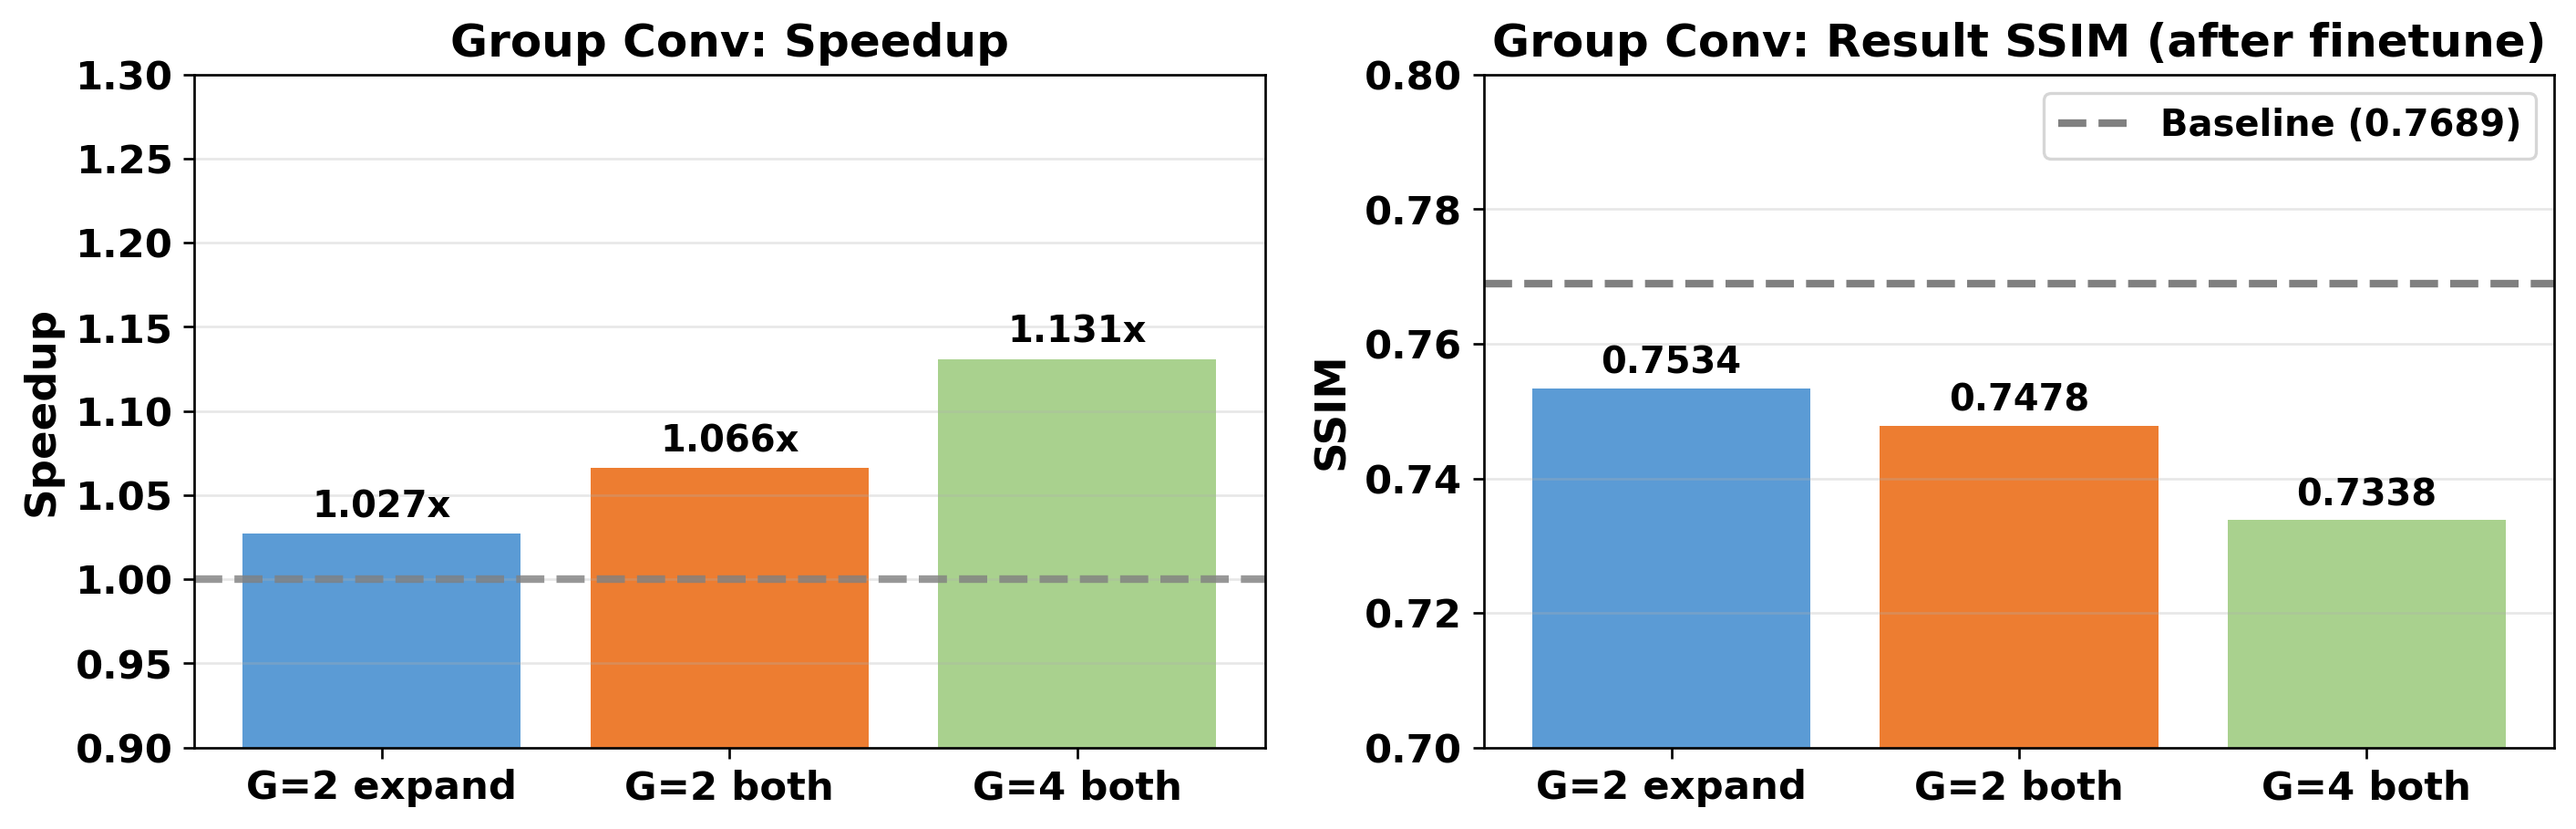

Вывод: group conv даёт 1.03–1.13x speedup при заметном падении SSIM (−0.015…−0.035).
Соотношение хуже чем у структурного прунинга.


In [25]:
group_results = [
    load('group2_expand.json'),
    load('group2_both.json'),
    load('group4_both.json'),
]
labels = ['G=2 expand', 'G=2 both', 'G=4 both']
baseline_ssim = group_results[0]['baseline']['ssim']

g_speedups = [d['speedup'] for d in group_results]
g_ssim_res = [d['result']['ssim'] for d in group_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(labels))
ax = axes[0]
bars = ax.bar(x, g_speedups, color=['#5B9BD5', '#ED7D31', '#A9D18E'])
ax.axhline(1.0, color='gray', linestyle='--', lw=2.5, alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Speedup')
ax.set_title('Group Conv: Speedup')
ax.set_ylim(0.9, 1.3)
for bar, val in zip(bars, g_speedups):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}x', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.axhline(baseline_ssim, color='gray', linestyle='--', lw=2.5, label=f'Baseline ({baseline_ssim:.4f})')
bars2 = ax.bar(x, g_ssim_res, color=['#5B9BD5', '#ED7D31', '#A9D18E'])
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('SSIM')
ax.set_title('Group Conv: Result SSIM (after finetune)')
ax.set_ylim(0.70, 0.80)
for bar, val in zip(bars2, g_ssim_res):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()
print('Вывод: group conv даёт 1.03–1.13x speedup при заметном падении SSIM (−0.015…−0.035).')
print('Соотношение хуже чем у структурного прунинга.')


---
## 3. Structural Pruning — лучший метод

**Идея:** физически удаляем наименее важные каналы из expand-свёртки каждого MBResBlock.

В `MBResBlock` структура: `in_ch → [expand: 1×1] → mid_ch → [depthwise: 3×3] → [project: 1×1] → out_ch`

Прунинг затрагивает `mid_ch` — внутреннюю размерность блока.  
**Важность канала** = L1-норма соответствующего фильтра expand-свёртки.  
Каналы с малой нормой убираем, пересобираем expand + depthwise + project с новым меньшим `mid_ch`.

Размерности `in_ch`/`out_ch` и skip-connections U-Net **не трогаем** → архитектура остаётся валидной.

**Почему работает быстрее?** Тензоры реально стали меньше. При 75% pruning `mid_ch` уменьшается в 4 раза,
FLOPs тоже в ~4 раза — процессор тратит меньше времени на матричные умножения.

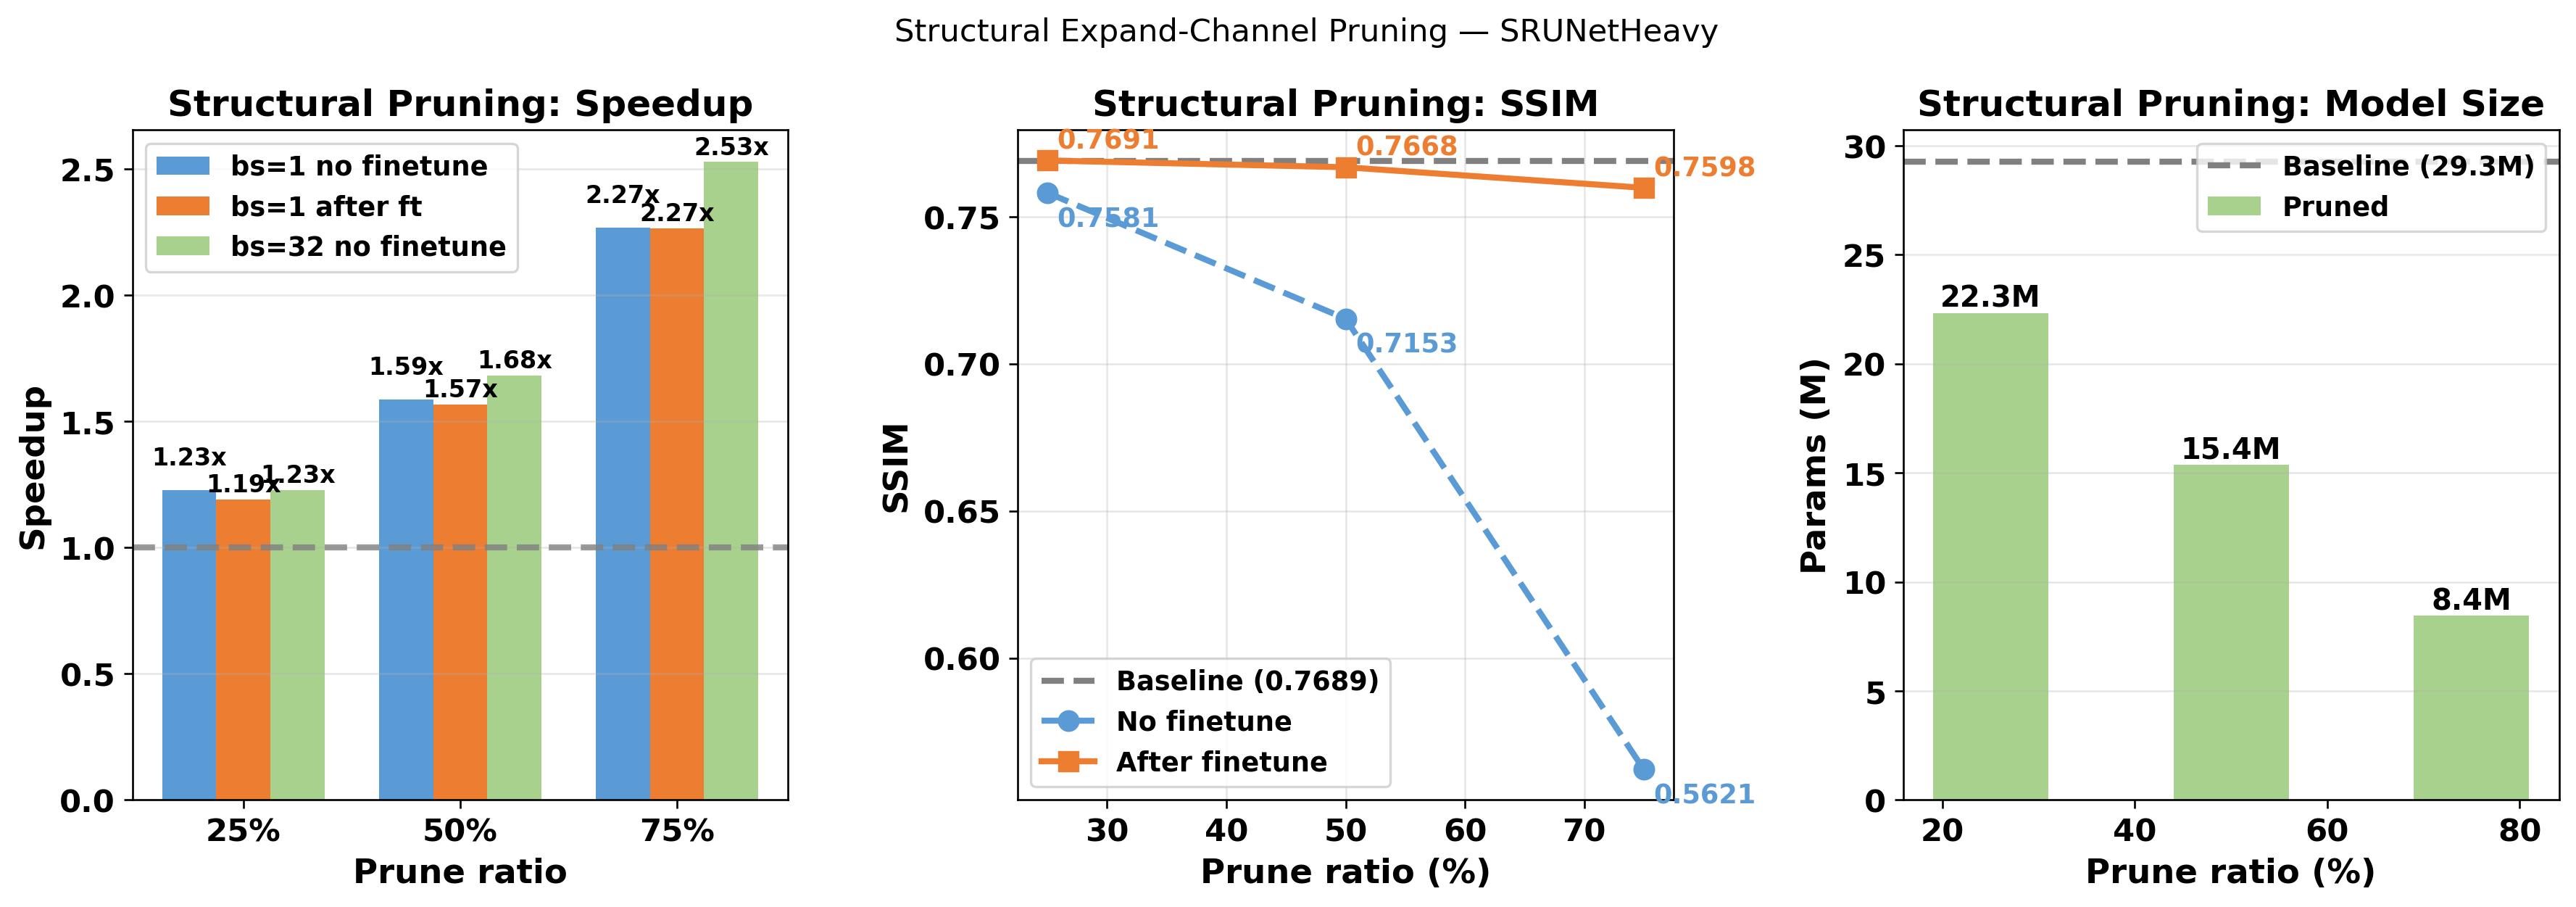


Итог (bs=1, after finetune):
  prune=25%: speedup=1.19x | SSIM 0.7689 -> 0.7691 (delta=-0.0002)
  prune=50%: speedup=1.57x | SSIM 0.7689 -> 0.7668 (delta=0.0021)
  prune=75%: speedup=2.27x | SSIM 0.7689 -> 0.7598 (delta=0.0091)

Итог (bs=32, no finetune):
  prune=25%: speedup=1.23x | SSIM 0.7689 -> 0.7581 (delta=0.0108)
  prune=50%: speedup=1.68x | SSIM 0.7689 -> 0.7153 (delta=0.0536)
  prune=75%: speedup=2.53x | SSIM 0.7689 -> 0.5621 (delta=0.2068)


In [42]:
struct_data = {
    25: {'no_ft': load('struct_25_no_ft.json'), 'ft': load('struct_25_ft.json'), 'bs32': load('struct_25_bs32.json')},
    50: {'no_ft': load('struct_50_no_ft.json'), 'ft': load('struct_50_ft.json'), 'bs32': load('struct_50_bs32.json')},
    75: {'no_ft': load('struct_75_no_ft.json'), 'ft': load('struct_75_ft.json'), 'bs32': load('struct_75_bs32.json')},
}

levels = [25, 50, 75]
baseline_ssim = struct_data[25]['no_ft']['baseline']['ssim']

speedup_no_ft = [struct_data[l]['no_ft']['speedup'] for l in levels]
speedup_ft    = [struct_data[l]['ft']['speedup']    for l in levels]
speedup_bs32  = [struct_data[l]['bs32']['speedup']  for l in levels]
ssim_no_ft    = [struct_data[l]['no_ft']['result']['ssim'] for l in levels]
ssim_ft       = [struct_data[l]['ft']['result']['ssim']    for l in levels]

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Speedup
ax1 = fig.add_subplot(gs[0])
x, w = np.arange(len(levels)), 0.25
b1 = ax1.bar(x - w, speedup_no_ft, w, label='bs=1 no finetune',  color='#5B9BD5')
b2 = ax1.bar(x,     speedup_ft,    w, label='bs=1 after ft',     color='#ED7D31')
b3 = ax1.bar(x + w, speedup_bs32,  w, label='bs=32 no finetune', color='#A9D18E')
ax1.axhline(1.0, color='gray', linestyle='--', lw=2.5, alpha=0.8)
ax1.set_xticks(x); ax1.set_xticklabels([f'{l}%' for l in levels])
ax1.set_xlabel('Prune ratio')
ax1.set_ylabel('Speedup')
ax1.set_title('Structural Pruning: Speedup')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
for bar, v in zip(b1, speedup_no_ft):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.08,
             f'{v:.2f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, v in list(zip(b2, speedup_ft)) + list(zip(b3, speedup_bs32)):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{v:.2f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')

# SSIM
ax2 = fig.add_subplot(gs[1])
ax2.axhline(baseline_ssim, color='gray', linestyle='--', lw=2.5, label=f'Baseline ({baseline_ssim:.4f})')
ax2.plot(levels, ssim_no_ft, 'o--', color='#5B9BD5', label='No finetune')
ax2.plot(levels, ssim_ft,    's-',  color='#ED7D31', label='After finetune')
for xi, y1, y2 in zip(levels, ssim_no_ft, ssim_ft):
    ax2.annotate(f'{y1:.4f}', (xi, y1), textcoords='offset points', xytext=(4, -14),
                 fontsize=11, fontweight='bold', color='#5B9BD5')
    ax2.annotate(f'{y2:.4f}', (xi, y2), textcoords='offset points', xytext=(4, 5),
                 fontsize=11, fontweight='bold', color='#ED7D31')
ax2.set_xlabel('Prune ratio (%)')
ax2.set_ylabel('SSIM')
ax2.set_title('Structural Pruning: SSIM')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

# Params
ax3 = fig.add_subplot(gs[2])
params_M = [struct_data[l]['ft']['result']['params_M'] for l in levels]
base_M   =  struct_data[25]['ft']['baseline']['params_M']
ax3.bar(levels, params_M, width=12, color='#A9D18E', label='Pruned')
ax3.axhline(base_M, color='gray', linestyle='--', lw=2.5, label=f'Baseline ({base_M:.1f}M)')
ax3.set_xlabel('Prune ratio (%)')
ax3.set_ylabel('Params (M)')
ax3.set_title('Structural Pruning: Model Size')
for xi, y in zip(levels, params_M):
    ax3.text(xi, y + 0.3, f'{y:.1f}M', ha='center', fontsize=12, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3)

fig.suptitle('Structural Expand-Channel Pruning — SRUNetHeavy', fontsize=13, y=1.01)
plt.show()

print('\nИтог (bs=1, after finetune):')
for l in levels:
    d = struct_data[l]['ft']
    print(f"  prune={l}%: speedup={d['speedup']:.2f}x | SSIM {d['baseline']['ssim']:.4f} -> {d['result']['ssim']:.4f} (delta={d['ssim_drop']:.4f})")
print('\nИтог (bs=32, no finetune):')
for l in levels:
    d = struct_data[l]['bs32']
    print(f"  prune={l}%: speedup={d['speedup']:.2f}x | SSIM {d['baseline']['ssim']:.4f} -> {d['result']['ssim']:.4f} (delta={d['ssim_drop']:.4f})")


---
## 4. 2:4 Semi-Structured Sparsity

**Что это:** NVIDIA аппаратный формат — в каждых 4 последовательных элементах веса ровно 2 нуля.  
Это позволяет хранить веса в 2× сжатом виде и выполнять матричные умножения в 2× быстрее через **cuSPARSELt**.

**Жёсткие ограничения:**
- Только **Ampere** GPU (A100, RTX 30xx/40xx), sm_80+. RTX 8000 = Turing (sm_75) — не поддерживается.
- Только **FP16/BF16** (не FP32)
- Только **`F.linear`** — НЕ работает с `F.conv2d` даже при kernel=1×1  
  → нужна обёртка `Pointwise2d`, которая роутит 1×1 conv через `F.linear`

**Почему результаты отрицательные (speedup < 1):**  
cuSPARSELt даёт выигрыш при высокой утилизации GPU — то есть при больших матрицах.  
При bs=1 и bs=32 матрицы маленькие, overhead на управление sparse-форматом превышает экономию на умножениях.  
Ожидается gain при bs ≥ 256–512. Также SSIM значительно упал (−0.067) из-за агрессивного 2:4 маскирования без файнтюна.

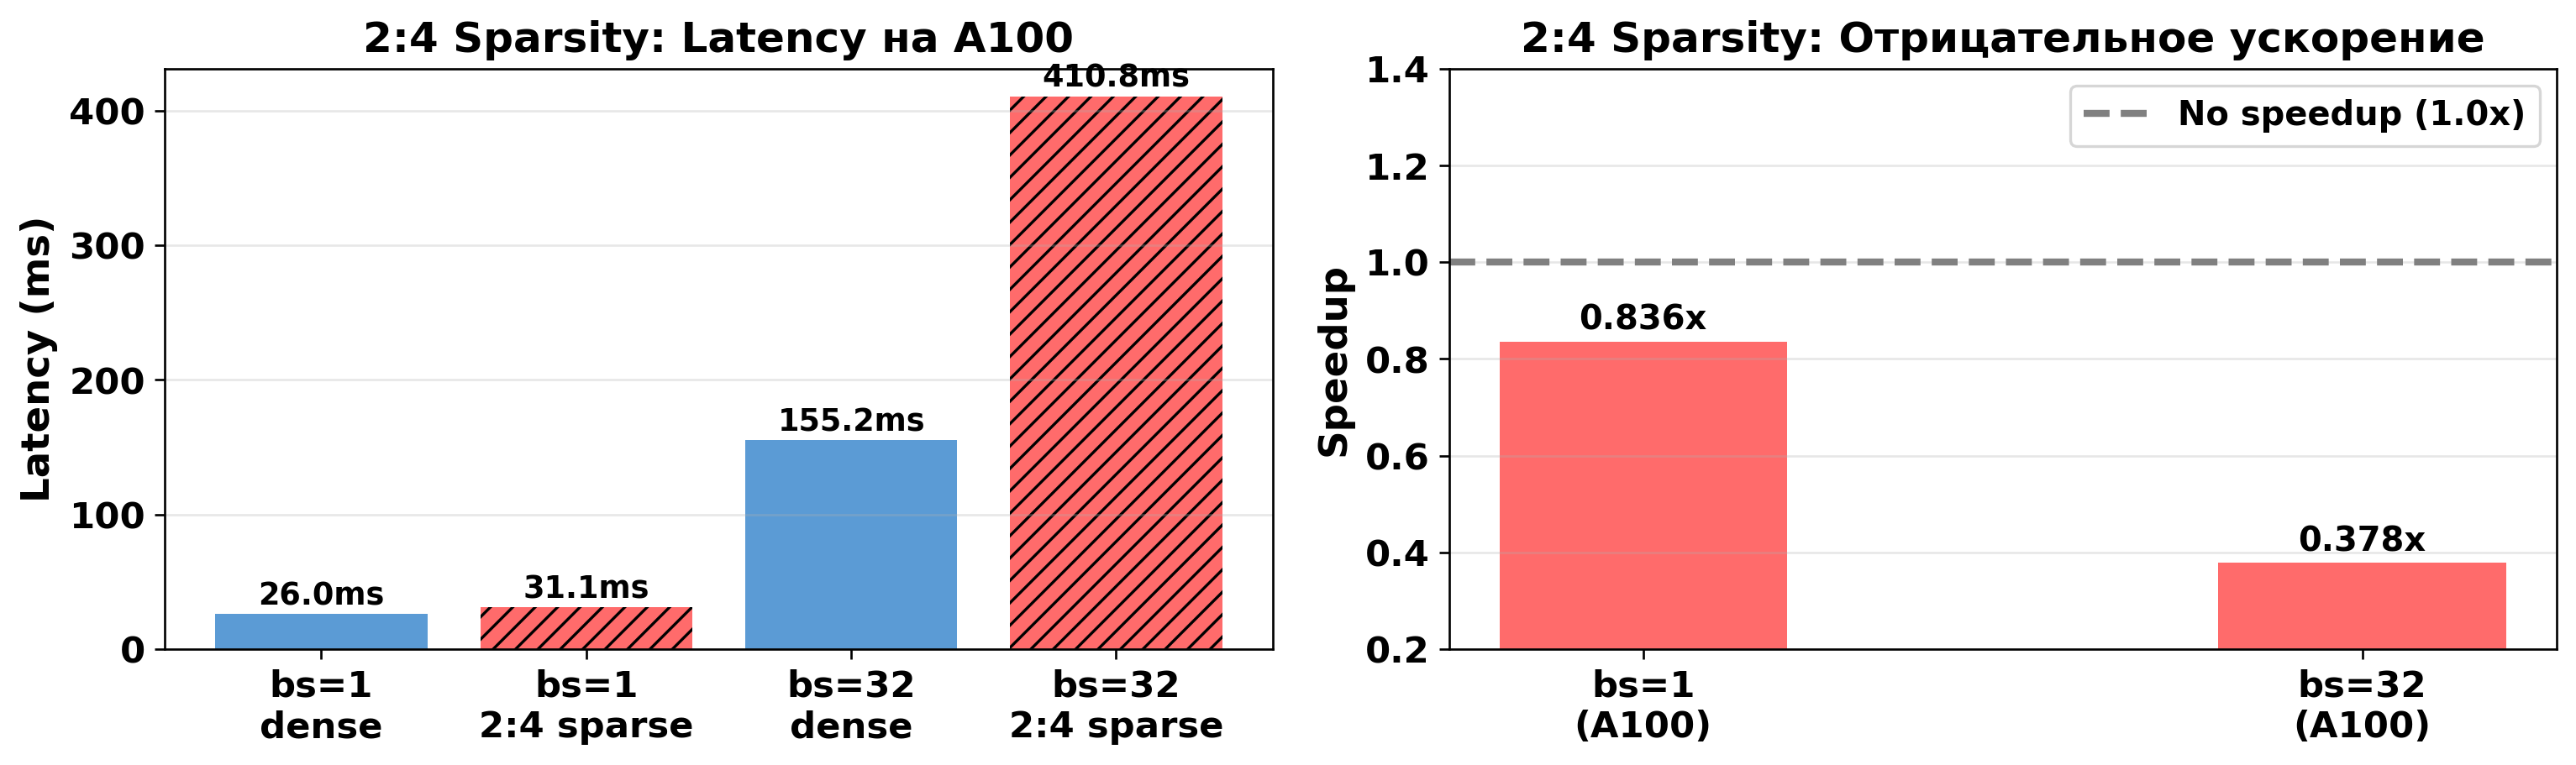

Вывод: 2:4 спарсность на A100 не дала ускорения ни при каком bs.
bs=1 : baseline 26.02ms -> sparse 31.14ms (speedup=0.836x)
bs=32: baseline 155.22ms -> sparse 410.76ms (speedup=0.378x)
Гипотеза: матрицы слишком маленькие -> overhead cuSPARSELt превышает выигрыш. Нужен bs >= 256.


In [27]:
sparse_bs1  = load('sparse_244_a100_fp16.json')
sparse_bs32 = load('sparse_244_a100_bs32.json')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
configs   = ['bs=1\ndense', 'bs=1\n2:4 sparse', 'bs=32\ndense', 'bs=32\n2:4 sparse']
latencies = [
    sparse_bs1['baseline']['latency_ms'],
    sparse_bs1['result']['latency_ms'],
    sparse_bs32['baseline']['latency_ms'],
    sparse_bs32['result']['latency_ms'],
]
colors = ['#5B9BD5', '#FF6B6B', '#5B9BD5', '#FF6B6B']
bars = ax.bar(configs, latencies, color=colors)
for bar, h in zip(bars, ['', '///', '', '///']):
    bar.set_hatch(h)
ax.set_ylabel('Latency (ms)')
ax.set_title('2:4 Sparsity: Latency на A100')
for bar, v in zip(bars, latencies):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            f'{v:.1f}ms', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(latencies) * 1.18)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
sp_labels = ['bs=1\n(A100)', 'bs=32\n(A100)']
sp_values = [sparse_bs1['speedup'], sparse_bs32['speedup']]
sp_colors = ['#FF6B6B' if v < 1 else '#A9D18E' for v in sp_values]
bars2 = ax2.bar(sp_labels, sp_values, color=sp_colors, width=0.4)
ax2.axhline(1.0, color='gray', linestyle='--', lw=2.5, label='No speedup (1.0x)')
ax2.set_ylabel('Speedup')
ax2.set_title('2:4 Sparsity: Отрицательное ускорение')
ax2.set_ylim(0.2, 1.4)
for bar, v in zip(bars2, sp_values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{v:.3f}x', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

print('Вывод: 2:4 спарсность на A100 не дала ускорения ни при каком bs.')
print(f"bs=1 : baseline {sparse_bs1['baseline']['latency_ms']}ms -> sparse {sparse_bs1['result']['latency_ms']}ms (speedup={sparse_bs1['speedup']}x)")
print(f"bs=32: baseline {sparse_bs32['baseline']['latency_ms']}ms -> sparse {sparse_bs32['result']['latency_ms']}ms (speedup={sparse_bs32['speedup']}x)")
print('Гипотеза: матрицы слишком маленькие -> overhead cuSPARSELt превышает выигрыш. Нужен bs >= 256.')


---
## 5. Torch Profiler: Dense vs Structural 75%

Сохраняем Chrome trace (`.json`) обоих моделей для просмотра в **Perfetto**:
1. Открыть [ui.perfetto.dev](https://ui.perfetto.dev)
2. Нажать **Open trace file** (или просто перетащить файл)
3. Загрузить `profiler_traces/dense_base.json` или `profiler_traces/struct_75_ft.json`

Разогрев происходит **до** профилировщика, в трейс попадают только горячие прогоны.

In [ ]:
import sys
sys.path.insert(0, str(Path('..').resolve()))

import torch
from torch.profiler import profile, record_function, ProfilerActivity
from src.model.heavy_model import SRUNetHeavy
from src.acceleration.prune_structured import prune_all_mbresblocks

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 256
INPUT_SIZE = (BATCH_SIZE, 3, 64, 64)
CKPT_BASE = '../checkpoints/heavy_srunet_29M.pt'
CKPT_PRUNED = '../checkpoints/struct_75_ft.pt'
TRACE_DIR = Path('profiler_traces')
TRACE_DIR.mkdir(exist_ok=True)

print(f'Device: {DEVICE}, input: {INPUT_SIZE}')


In [ ]:
def load_model(ckpt_path, prune_ratio=None):
    model = SRUNetHeavy(
        in_channels=3, out_channels=3, base_channels=96,
        expand_ratio=4, se_bottleneck_ratio=4, residual=True, num_groups=8,
    ).to(DEVICE)
    if prune_ratio is not None:
        prune_all_mbresblocks(model, prune_ratio, num_groups=8)
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model


def save_trace(model, name, n_warmup=20, n_active=3):
    x = torch.randn(*INPUT_SIZE, device=DEVICE)
    out_path = str(TRACE_DIR / f'{name}.json')

    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(x)
    if DEVICE == 'cuda':
        torch.cuda.synchronize()

    activities = [ProfilerActivity.CPU]
    if DEVICE == 'cuda':
        activities.append(ProfilerActivity.CUDA)

    with profile(activities=activities, record_shapes=True, with_stack=False) as prof:
        with torch.no_grad():
            for _ in range(n_active):
                with record_function(f'{name}_forward'):
                    _ = model(x)

    prof.export_chrome_trace(out_path)
    print(f'[{name}] trace saved -> {out_path}')
    print(prof.key_averages().table(sort_by='cuda_time_total', row_limit=8))
    return prof


print('--- Dense baseline ---')
model_dense = load_model(CKPT_BASE)
prof_dense  = save_trace(model_dense, 'dense_base')
del model_dense
if DEVICE == 'cuda': torch.cuda.empty_cache()

print('\n--- Struct 75% pruned + finetuned ---')
model_pruned = load_model(CKPT_PRUNED, prune_ratio=0.75)
prof_pruned  = save_trace(model_pruned, 'struct_75_ft')
del model_pruned
if DEVICE == 'cuda': torch.cuda.empty_cache()

print(f'\nТрейсы в: {TRACE_DIR.resolve()}')


--- Dense baseline ---
[dense_base] trace saved -> profiler_traces/dense_base.json
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                     dense_base_forward         0.00%       0.000us         0.00%       0.000us       0.000us     619.869ms       100.06%     619.869ms     206.623ms             3  
                                     dense_base_forward         1.79%      11.847ms         7.76%      51.286ms      17.095m